<a href="https://colab.research.google.com/github/Rouba-Os/AI-Course/blob/main/Assignment9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!apt-get install -y git
!git config --global user.email "rouba.osko@students.williscollege.com"
!git config --global user.name "Rouba-Os"

print("Git configured successfully")

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
git is already the newest version (1:2.34.1-1ubuntu1.17).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
Git configured successfully


In [2]:
!git clone https://github.com/Rouba-Os/AI-Course.git
%cd AI-Course
!ls

Cloning into 'AI-Course'...
remote: Enumerating objects: 45, done.
remote: Counting objects: 100% (45/45), done.
remote: Compressing objects: 100% (43/43), done.
remote: Total 45 (delta 23), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (45/45), 626.65 KiB | 6.81 MiB/s, done.
Resolving deltas: 100% (23/23), done.
/content/AI-Course
AICourse.ipynb	   Assignment5.ipynb  Assignment8.ipynb
assignment2.ipynb  Assignment6.ipynb  git_github_exercise.ipynb
Assignment3.ipynb  Assignment7.ipynb  README.md


In [3]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [4]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [5]:
# Load dataset
data = load_iris()
X = pd.DataFrame(data.data, columns=data.feature_names)

In [10]:
# Data Check
print('Data first few rows\n', X.head())

print('\nData info\n', X.info())

print('\nData statistical summary\n', X.describe())

Data first few rows
    sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB

Data info
 None

Data statistical summary
        sepal length (cm)  sepal width (cm)  pet

In [12]:
# Check Missing Values
print('\nMissing values:\n', X.isnull().sum())


Missing values:
 sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
dtype: int64


In [14]:
# Preprocessing

## Handle missing values
imputer = SimpleImputer(strategy='mean')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

## Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

In [15]:
# Determine the optimal number of clusters using Elbow Method and Silhouette Score
inertia_list = []
silhouette_list = []

for k in range(2,7):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)

    inertia_list.append(km.inertia_)
    silhouette_list.append(silhouette_score(X_scaled, km.labels_))

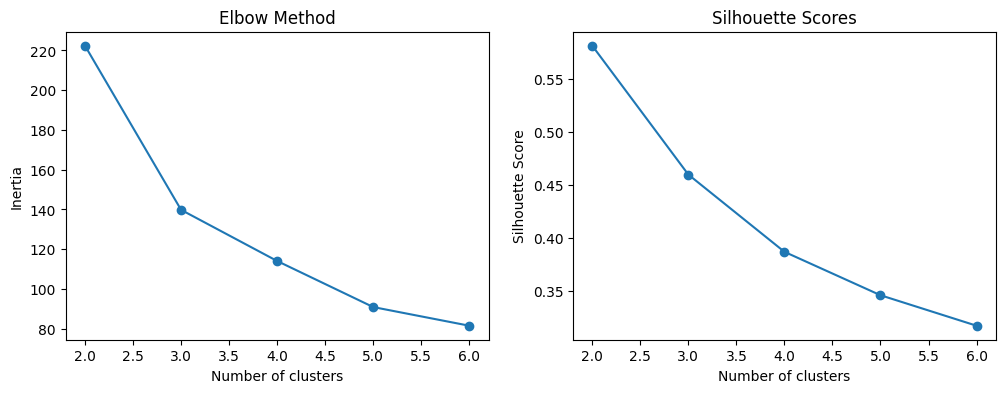

In [16]:
# Plot Elbow Method and Silhouette Scores
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(range(2,7), inertia_list, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")

plt.subplot(1,2,2)
plt.plot(range(2,7), silhouette_list, marker='o')
plt.title("Silhouette Scores")
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette Score")

plt.show()

In [17]:
# Apply Clustering

# KMeans
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_kmeans = kmeans.fit_predict(X_scaled)

# Hierarchical
agg = AgglomerativeClustering(n_clusters=3)
labels_agg = agg.fit_predict(X_scaled)

In [18]:
# Calculate and print Silhouette Scores for both clustering methods
sil_score_kmeans = silhouette_score(X_scaled, labels_kmeans)
sil_score_agg = silhouette_score(X_scaled, labels_agg)

print("KMeans Silhouette Score:", sil_score_kmeans)
print("Hierarchical Silhouette Score:", sil_score_agg)

KMeans Silhouette Score: 0.45994823920518635
Hierarchical Silhouette Score: 0.4466890410285909


In [19]:
# Reduce dimensions using PCA for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['KMeans_Cluster'] = labels_kmeans
df_pca['Hierarchical_Cluster'] = labels_agg

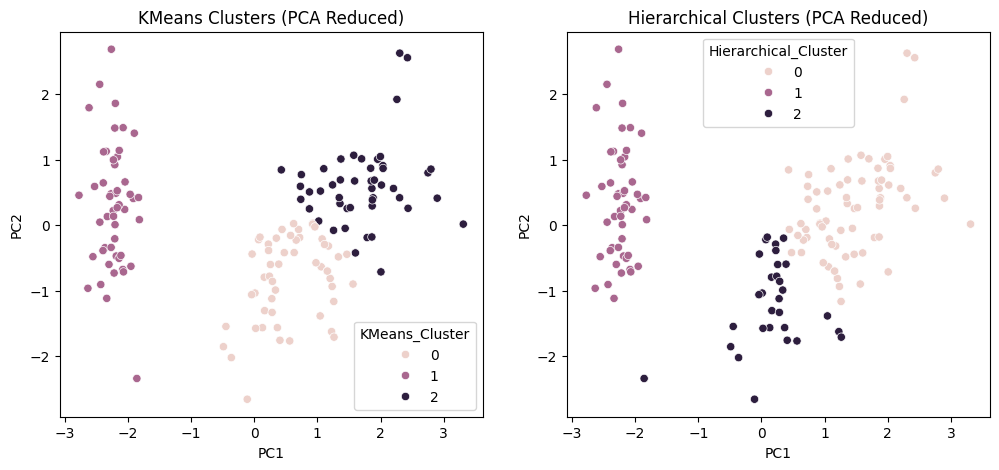

In [20]:
# Visualization

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.scatterplot(x='PC1', y='PC2', hue='KMeans_Cluster', data=df_pca)
plt.title("KMeans Clusters (PCA Reduced)")

plt.subplot(1,2,2)
sns.scatterplot(x='PC1', y='PC2', hue='Hierarchical_Cluster', data=df_pca)
plt.title("Hierarchical Clusters (PCA Reduced)")

plt.show()